GPU-accelerated artificial life simulation using CUDA and the Gray-Scott reaction-diffusion model to generate emergent biological patterns through massively parallel cellular interactions.
CUDA + C++ + Reaction-Diffusion + GPU Computing + Emergent Behavior + Artificial Life + Parallel Stencil Computation

In [1]:
!nvidia-smi
!nvcc --version

/bin/bash: line 1: nvidia-smi: command not found
/bin/bash: line 1: nvcc: command not found


In [2]:
!pip -q install numpy matplotlib pillow

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Python enviroment ready.")

Python enviroment ready.


In [1]:
print('Yeniden derleniyor...')

Yeniden derleniyor...


In [2]:
!nvcc -O3 -std=c++17 artificial_life.cu -o artificial_life

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
cc1plus: fatal error: artificial_life.cu: No such file or directory
compilation terminated.


In [3]:
print('Simülasyon çalıştırılıyor...')

Simülasyon çalıştırılıyor...


In [4]:
!./artificial_life 5000 2048 2048

/bin/bash: line 1: ./artificial_life: No such file or directory


In [5]:
print('artificial_life.cu dosyasını yeniden oluşturuluyor...')

artificial_life.cu dosyasını yeniden oluşturuluyor...


In [6]:
%%writefile artificial_life.cu

#include <cuda_runtime.h>

#include <iostream>
#include <fstream>
#include <cmath>
#include <cstdlib>
#include <chrono>

#define CUDA_CHECK(call)                                                   \
do {                                                                       \
    cudaError_t err = call;                                                \
    if (err != cudaSuccess) {                                              \
        std::cerr << "CUDA ERROR: " << cudaGetErrorString(err)             \
                  << " at " << __FILE__ << ":" << __LINE__ << std::endl;   \
        exit(EXIT_FAILURE);                                                \
    }                                                                      \
} while (0)


// ============================================================
// Gray-Scott Reaction-Diffusion
//
// du/dt = Du * Laplacian(U) - U*V^2 + F*(1-U)
// dv/dt = Dv * Laplacian(V) + U*V^2 - (F+k)*V
//
// Each CUDA thread updates one cell.
// ============================================================

__device__ __forceinline__
int index2D(int x, int y, int width, int height)
{
    // Clamped boundaries
    x = max(0, min(width - 1, x));
    y = max(0, min(height - 1, y));

    return y * width + x;
}


// ------------------------------------------------------------
// Initialization
// ------------------------------------------------------------

__global__
void initialize(
    float* U,
    float* V,
    int width,
    int height
)
{
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height)
        return;

    int id = y * width + x;

    U[id] = 1.0f;
    V[id] = 0.0f;

    // Central perturbation
    float cx = width  * 0.5f;
    float cy = height * 0.5f;

    float dx = x - cx;
    float dy = y - cy;

    float r2 = dx * dx + dy * dy;

    if (r2 < 35.0f * 35.0f)
    {
        U[id] = 0.50f;
        V[id] = 0.25f;
    }

    // Additional small deterministic perturbations
    unsigned int seed =
        (unsigned int)(x * 1973 + y * 9277 + 89173);

    seed ^= seed << 13;
    seed ^= seed >> 17;
    seed ^= seed << 5;

    float noise = (seed % 1000) / 1000.0f;

    if (r2 < 55.0f * 55.0f && noise > 0.65f)
    {
        U[id] = 0.45f;
        V[id] = 0.30f;
    }
}


// ------------------------------------------------------------
// Gray-Scott update
// ------------------------------------------------------------

__global__
void reactionDiffusion(
    const float* U,
    const float* V,
    float* Unew,
    float* Vnew,
    int width,
    int height,
    float Du,
    float Dv,
    float F,
    float K,
    float dt
)
{
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height)
        return;

    int id = y * width + x;

    float u = U[id];
    float v = V[id];

    // --------------------------------------------------------
    // 9-point Laplacian
    //
    //      0.05  0.20  0.05
    //      0.20 -1.00  0.20
    //      0.05  0.20  0.05
    // --------------------------------------------------------

    float lapU =
          -1.00f * U[index2D(x,   y,   width, height)]
        +  0.20f * U[index2D(x-1, y,   width, height)]
        +  0.20f * U[index2D(x+1, y,   width, height)]
        +  0.20f * U[index2D(x,   y-1, width, height)]
        +  0.20f * U[index2D(x,   y+1, width, height)]
        +  0.05f * U[index2D(x-1, y-1, width, height)]
        +  0.05f * U[index2D(x+1, y-1, width, height)]
        +  0.05f * U[index2D(x-1, y+1, width, height)]
        +  0.05f * U[index2D(x+1, y+1, width, height)];

    float lapV =
          -1.00f * V[index2D(x,   y,   width, height)]
        +  0.20f * V[index2D(x-1, y,   width, height)]
        +  0.20f * V[index2D(x+1, y,   width, height)]
        +  0.20f * V[index2D(x,   y-1, width, height)]
        +  0.20f * V[index2D(x,   y+1, width, height)]
        +  0.05f * V[index2D(x-1, y-1, width, height)]
        +  0.05f * V[index2D(x+1, y-1, width, height)]
        +  0.05f * V[index2D(x-1, y+1, width, height)]
        +  0.05f * V[index2D(x+1, y+1, width, height)];

    // Chemical reaction
    float reaction = u * v * v;

    // Gray-Scott equations
    float du =
        Du * lapU
        - reaction
        + F * (1.0f - u);

    float dv =
        Dv * lapV
        + reaction
        - (F + K) * v;

    float newU = u + du * dt;
    float newV = v + dv * dt;

    // Numerical safety
    newU = fminf(1.0f, fmaxf(0.0f, newU));
    newV = fminf(1.0f, fmaxf(0.0f, newV));

    Unew[id] = newU;
    Vnew[id] = newV;
}


// ------------------------------------------------------------
// Save floating-point field
// ------------------------------------------------------------

void saveField(
    const char* filename,
    const float* data,
    int size
)
{
    std::ofstream file(filename, std::ios::binary);

    if (!file)
    {
        std::cerr << "Could not open " << filename << std::endl;
        return;
    }

    file.write(
        reinterpret_cast<const char*>(data),
        size * sizeof(float)
    );

    file.close();
}


// ============================================================
// MAIN
// ============================================================

int main(int argc, char** argv)
{
    int width  = 2048;
    int height = 2048;

    int iterations = 5000;

    // Gray-Scott parameters
    float Du = 0.16f;
    float Dv = 0.08f;

    // Pattern-forming parameters
    float F = 0.0367f;
    float K = 0.0649f;

    float dt = 1.0f;

    // Optional command line arguments
    if (argc > 1)
        iterations = std::atoi(argv[1]);

    if (argc > 2)
        width = std::atoi(argv[2]);

    if (argc > 3)
        height = std::atoi(argv[3]);

    std::cout << "\n";
    std::cout << "=========================================\n";
    std::cout << " CUDA ARTIFICIAL LIFE ENGINE\n";
    std::cout << " Gray-Scott Reaction-Diffusion\n";
    std::cout << "=========================================\n";

    std::cout << "Grid        : "
              << width << " x " << height << "\n";

    std::cout << "Cells       : "
              << width * height << "\n";

    std::cout << "Iterations  : "
              << iterations << "\n";

    std::cout << "F           : "
              << F << "\n";

    std::cout << "K           : "
              << K << "\n";

    // --------------------------------------------------------
    // GPU memory
    // --------------------------------------------------------

    size_t N = (size_t)width * height;
    size_t bytes = N * sizeof(float);

    float* U;
    float* V;
    float* Unew;
    float* Vnew;

    CUDA_CHECK(cudaMalloc(&U,    bytes));
    CUDA_CHECK(cudaMalloc(&V,    bytes));
    CUDA_CHECK(cudaMalloc(&Unew, bytes));
    CUDA_CHECK(cudaMalloc(&Vnew, bytes));

    dim3 block(16, 16);

    dim3 grid(
        (width  + block.x - 1) / block.x,
        (height + block.y - 1) / block.y
    );

    // --------------------------------------------------------
    // Initialize
    // --------------------------------------------------------

    initialize<<<grid, block>>>(
        U,
        V,
        width,
        height
    );

    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    std::cout << "\nGPU simulation started...\n";

    // --------------------------------------------------------
    // Timing
    // --------------------------------------------------------

    cudaEvent_t start, stop;

    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    CUDA_CHECK(cudaEventRecord(start));

    // --------------------------------------------------------
    // Main simulation
    // --------------------------------------------------------

    for (int step = 0; step < iterations; ++step)
    {
        reactionDiffusion<<<grid, block>>>(
            U,
            V,
            Unew,
            Vnew,
            width,
            height,
            Du,
            Dv,
            F,
            K,
            dt
        );

        // Ping-pong buffers
        std::swap(U, Unew);
        std::swap(V, Vnew);

        if (step % 500 == 0)
        {
            std::cout
                << "Iteration "
                << step
                << " / "
                << iterations
                << "\n";
        }
    }

    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float milliseconds = 0.0f;

    CUDA_CHECK(cudaEventElapsedTime(
        &milliseconds,
        start,
        stop
    ));

    std::cout << "\nSimulation finished.\n";

    std::cout << "GPU time: "
              << milliseconds / 1000.0f
              << " seconds\n";

    // --------------------------------------------------------
    // Copy result GPU -> CPU
    // --------------------------------------------------------

    float* hostU =
        (float*)malloc(bytes);

    float* hostV =
        (float*)malloc(bytes);

    CUDA_CHECK(cudaMemcpy(
        hostU,
        U,
        bytes,
        cudaMemcpyDeviceToHost
    ));

    CUDA_CHECK(cudaMemcpy(
        hostV,
        V,
        bytes,
        cudaMemcpyDeviceToHost
    ));

    // --------------------------------------------------------
    // Save
    // --------------------------------------------------------

    saveField(
        "U_final.bin",
        hostU,
        N
    );

    saveField(
        "V_final.bin",
        hostV,
        N
    );

    std::cout << "Saved U_final.bin\n";
    std::cout << "Saved V_final.bin\n";

    // --------------------------------------------------------
    // Cleanup
    // --------------------------------------------------------

    free(hostU);
    free(hostV);

    CUDA_CHECK(cudaFree(U));
    CUDA_CHECK(cudaFree(V));
    CUDA_CHECK(cudaFree(Unew));
    CUDA_CHECK(cudaFree(Vnew));

    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    std::cout << "\nCUDA Artificial Life complete.\n";

    return 0;
}

Writing artificial_life.cu


In [7]:
print('Yeniden derleniyor...')

Yeniden derleniyor...


In [8]:
!nvcc -O3 -std=c++17 artificial_life.cu -o artificial_life

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [9]:
print('Simülasyon çalıştırılıyor...')

Simülasyon çalıştırılıyor...


In [10]:
!./artificial_life 5000 2048 2048


 CUDA ARTIFICIAL LIFE ENGINE
 Gray-Scott Reaction-Diffusion
Grid        : 2048 x 2048
Cells       : 4194304
Iterations  : 5000
F           : 0.0367
K           : 0.0649

GPU simulation started...
Iteration 0 / 5000
Iteration 500 / 5000
Iteration 1000 / 5000
Iteration 1500 / 5000
Iteration 2000 / 5000
Iteration 2500 / 5000
Iteration 3000 / 5000
Iteration 3500 / 5000
Iteration 4000 / 5000
Iteration 4500 / 5000

Simulation finished.
GPU time: 1.76997 seconds
Saved U_final.bin
Saved V_final.bin

CUDA Artificial Life complete.


U range: 0.2766724 1.0
V range: 0.0 0.41708505


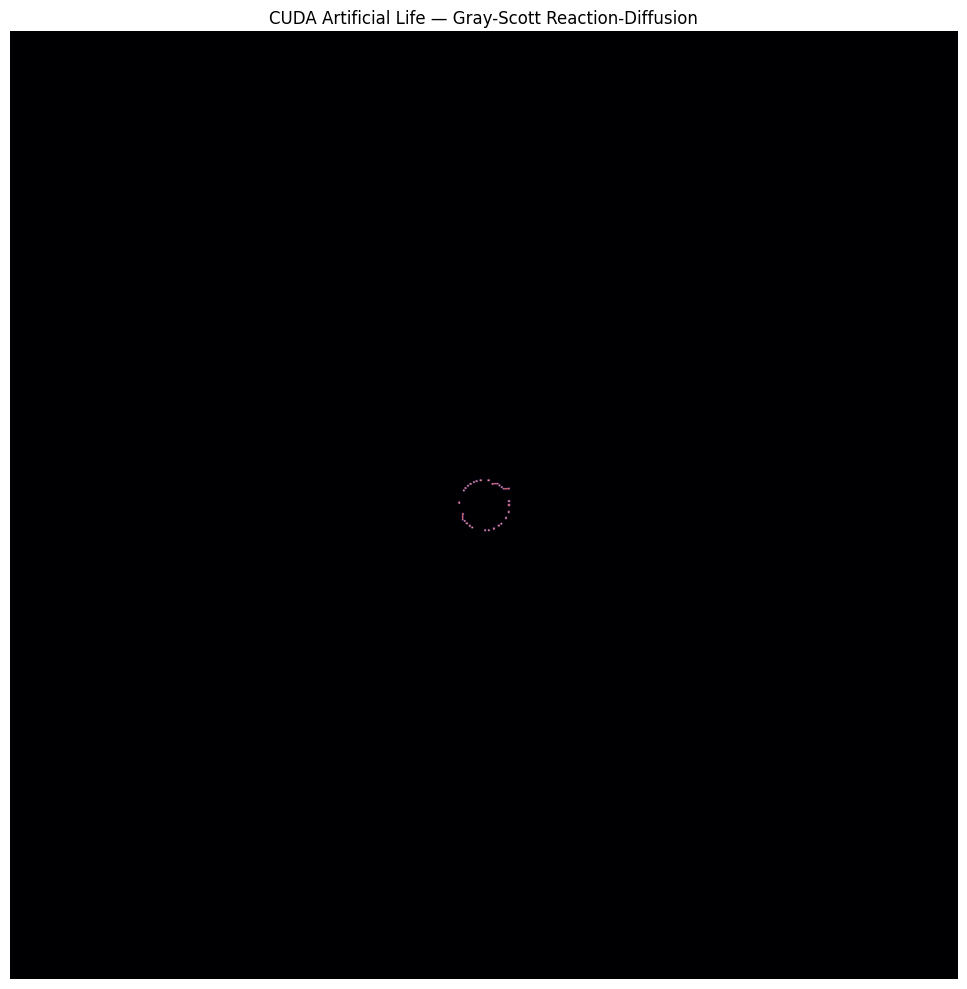

In [37]:
import numpy as np
import matplotlib.pyplot as plt

W = 2048
H = 2048

U = np.fromfile(
    "U_final.bin",
    dtype=np.float32
).reshape(H, W)

V = np.fromfile(
    "V_final.bin",
    dtype=np.float32
).reshape(H, W)

print("U range:", U.min(), U.max())
print("V range:", V.min(), V.max())

plt.figure(figsize=(10, 10))

plt.imshow(
    V,
    cmap="magma",
    interpolation="bilinear"
)

plt.axis("off")
plt.title(
    "CUDA Artificial Life — Gray-Scott Reaction-Diffusion"
)

plt.tight_layout()

plt.savefig(
    "cuda_artificial_life.png",
    dpi=200,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

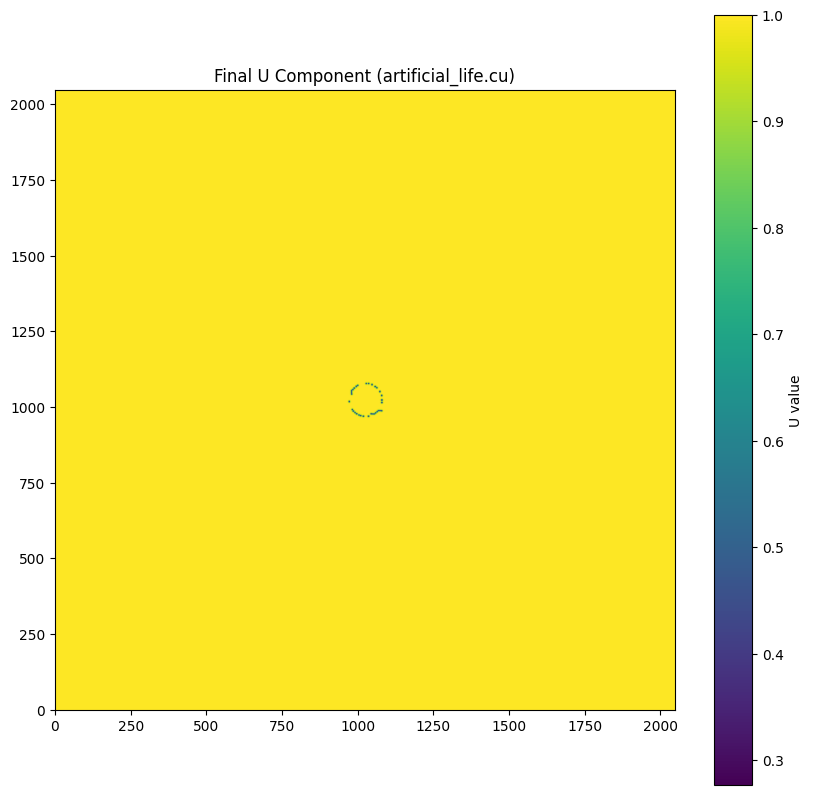

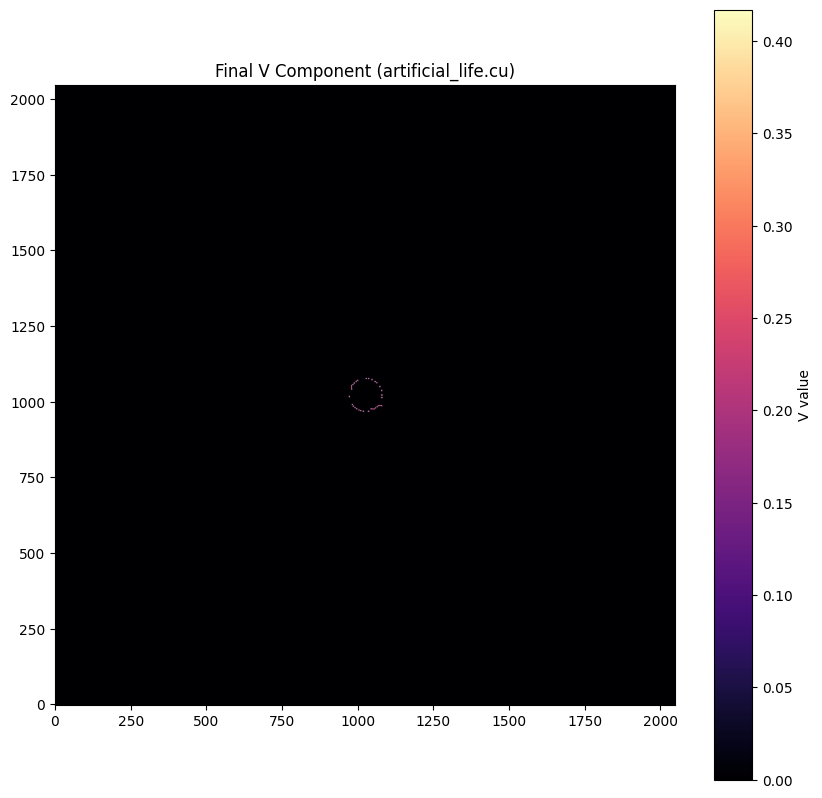

Görselleştirme tamamlandı.


In [38]:
import numpy as np
import matplotlib.pyplot as plt

width = 2048
height = 2048
N = width * height

# Load U_final.bin
with open('U_final.bin', 'rb') as f:
    U_data = np.fromfile(f, dtype=np.float32)
U_data = U_data.reshape(height, width)

# Load V_final.bin
with open('V_final.bin', 'rb') as f:
    V_data = np.fromfile(f, dtype=np.float32)
V_data = V_data.reshape(height, width)

# Visualize the U component
plt.figure(figsize=(10, 10))
plt.imshow(U_data, cmap='viridis', origin='lower')
plt.colorbar(label='U value')
plt.title('Final U Component (artificial_life.cu)')
plt.show()

# Visualize the V component
plt.figure(figsize=(10, 10))
plt.imshow(V_data, cmap='magma', origin='lower')
plt.colorbar(label='V value')
plt.title('Final V Component (artificial_life.cu)')
plt.show()

print('Görselleştirme tamamlandı.')

In [41]:
%%writefile artificial_life_realtime.cu

#include <cuda_runtime.h>

#include <iostream>
#include <cmath>
#include <cstdlib>
#include <algorithm>

#define CUDA_CHECK(x)                                                     \
do {                                                                      \
    cudaError_t err = x;                                                  \
    if (err != cudaSuccess) {                                              \
        std::cerr << "CUDA ERROR: " << cudaGetErrorString(err)            \
                  << " | line " << __LINE__ << std::endl;                 \
        exit(EXIT_FAILURE);                                               \
    }                                                                     \
} while(0)


// ============================================================
// GRAY-SCOTT REACTION-DIFFUSION
// ============================================================

__device__
int idx(int x, int y, int W, int H)
{
    x = max(0, min(W - 1, x));
    y = max(0, min(H - 1, y));

    return y * W + x;
}


// ============================================================
// INITIALIZATION
// ============================================================

__global__
void initialize(
    float* U,
    float* V,
    int W,
    int H
)
{
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= W || y >= H)
        return;

    int p = y * W + x;

    U[p] = 1.0f;
    V[p] = 0.0f;

    float cx = W * 0.5f;
    float cy = H * 0.5f;

    float dx = x - cx;
    float dy = y - cy;

    float r = sqrtf(dx * dx + dy * dy);

    // Initial chemical seed
    if (r < 45.0f)
    {
        U[p] = 0.50f;
        V[p] = 0.25f;
    }

    // Deterministic noise around the seed
    unsigned int seed =
        x * 1973u +
        y * 9277u +
        89173u;

    seed ^= seed << 13;
    seed ^= seed >> 17;
    seed ^= seed << 5;

    float noise =
        (seed % 1000) / 1000.0f;

    if (r < 70.0f && noise > 0.68f)
    {
        U[p] = 0.45f;
        V[p] = 0.30f;
    }
}


// ============================================================
// GRAY-SCOTT UPDATE
// ============================================================

__global__
void grayScott(
    const float* U,
    const float* V,
    float* Un,
    float* Vn,
    int W,
    int H,
    float Du,
    float Dv,
    float F,
    float K,
    float dt
)
{
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= W || y >= H)
        return;

    int p = y * W + x;

    float u = U[p];
    float v = V[p];

    // --------------------------------------------------------
    // 9-point Laplacian
    // --------------------------------------------------------

    float lapU =
        -1.00f * U[idx(x,   y,   W, H)]
        + 0.20f * U[idx(x-1, y,   W, H)]
        + 0.20f * U[idx(x+1, y,   W, H)]
        + 0.20f * U[idx(x,   y-1, W, H)]
        + 0.20f * U[idx(x,   y+1, W, H)]
        + 0.05f * U[idx(x-1, y-1, W, H)]
        + 0.05f * U[idx(x+1, y-1, W, H)]
        + 0.05f * U[idx(x-1, y+1, W, H)]
        + 0.05f * U[idx(x+1, y+1, W, H)];

    float lapV =
        -1.00f * V[idx(x,   y,   W, H)]
        + 0.20f * V[idx(x-1, y,   W, H)]
        + 0.20f * V[idx(x+1, y,   W, H)]
        + 0.20f * V[idx(x,   y-1, W, H)]
        + 0.20f * V[idx(x,   y+1, W, H)]
        + 0.05f * V[idx(x-1, y-1, W, H)]
        + 0.05f * V[idx(x+1, y-1, W, H)]
        + 0.05f * V[idx(x-1, y+1, W, H)]
        + 0.05f * V[idx(x+1, y+1, W, H)];

    // Chemical reaction
    float reaction = u * v * v;

    // Gray-Scott equations
    float du =
        Du * lapU
        - reaction
        + F * (1.0f - u);

    float dv =
        Dv * lapV
        + reaction
        - (F + K) * v;

    float newU = u + du * dt;
    float newV = v + dv * dt;

    // Numerical stability
    newU = fminf(1.0f, fmaxf(0.0f, newU));
    newV = fminf(1.0f, fmaxf(0.0f, newV));

    Un[p] = newU;
    Vn[p] = newV;
}


// ============================================================
// MAIN
// ============================================================

int main(int argc, char** argv)
{
    int W = 1024;
    int H = 1024;

    int totalSteps = 15000;
    int outputEvery = 50;

    if (argc > 1)
        totalSteps = std::atoi(argv[1]);

    if (argc > 2)
        W = std::atoi(argv[2]);

    if (argc > 3)
        H = std::atoi(argv[3]);

    if (argc > 4)
        outputEvery = std::atoi(argv[4]);

    std::cout << "\n";
    std::cout << "=========================================\n";
    std::cout << " CUDA ARTIFICIAL LIFE LAB\n";
    std::cout << " Real-Time Gray-Scott Engine\n";
    std::cout << "=========================================\n";

    std::cout << "Grid       : "
              << W << " x " << H << "\n";

    std::cout << "Iterations : "
              << totalSteps << "\n";

    std::cout << "Frame step : "
              << outputEvery << "\n";

    std::cout << "\n";

    size_t N = (size_t)W * H;
    size_t bytes = N * sizeof(float);

    float *U, *V;
    float *Un, *Vn;

    CUDA_CHECK(cudaMalloc(&U,  bytes));
    CUDA_CHECK(cudaMalloc(&V,  bytes));
    CUDA_CHECK(cudaMalloc(&Un, bytes));
    CUDA_CHECK(cudaMalloc(&Vn, bytes));

    dim3 block(16, 16);

    dim3 grid(
        (W + block.x - 1) / block.x,
        (H + block.y - 1) / block.y
    );

    initialize<<<grid, block>>>(
        U,
        V,
        W,
        H
    );

    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    float* hostV =
        (float*)malloc(bytes);

    std::cout << "Simulation running...\n";

    // ========================================================
    // SIMULATION LOOP
    // ========================================================

    for (int step = 0;
         step < totalSteps;
         step++)
    {
        grayScott<<<grid, block>>>(
            U,
            V,
            Un,
            Vn,
            W,
            H,

            // Diffusion
            0.16f,
            0.08f,

            // Feed / kill
            0.0367f,
            0.0649f,

            // Time step
            1.0f
        );

        CUDA_CHECK(cudaGetLastError());

        // Ping-pong
        std::swap(U, Un);
        std::swap(V, Vn);

        // ----------------------------------------------------
        // Send current state to CPU for visualization
        // ----------------------------------------------------

        if (step % outputEvery == 0)
        {
            CUDA_CHECK(cudaMemcpy(
                hostV,
                V,
                bytes,
                cudaMemcpyDeviceToHost
            ));

            // Raw binary frame
            char filename[128];

            sprintf(
                filename,
                "frame_%06d.bin",
                step
            );

            FILE* f = fopen(
                filename,
                "wb"
            );

            fwrite(
                hostV,
                sizeof(float),
                N,
                f
            );

            fclose(f);

            std::cout
                << "FRAME "
                << step
                << " / "
                << totalSteps
                << "\n";
        }
    }

    std::cout << "\nSimulation finished.\n";

    free(hostV);

    CUDA_CHECK(cudaFree(U));
    CUDA_CHECK(cudaFree(V));
    CUDA_CHECK(cudaFree(Un));
    CUDA_CHECK(cudaFree(Vn));

    return 0;
}

Writing artificial_life_realtime.cu


In [42]:
!nvcc -O3 -std=c++17 artificial_life_realtime.cu -o artificial_life_realtime

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [43]:
!./artificial_life_realtime 15000 1024 1024 50


 CUDA ARTIFICIAL LIFE LAB
 Real-Time Gray-Scott Engine
Grid       : 1024 x 1024
Iterations : 15000
Frame step : 50

Simulation running...
FRAME 0 / 15000
FRAME 50 / 15000
FRAME 100 / 15000
FRAME 150 / 15000
FRAME 200 / 15000
FRAME 250 / 15000
FRAME 300 / 15000
FRAME 350 / 15000
FRAME 400 / 15000
FRAME 450 / 15000
FRAME 500 / 15000
FRAME 550 / 15000
FRAME 600 / 15000
FRAME 650 / 15000
FRAME 700 / 15000
FRAME 750 / 15000
FRAME 800 / 15000
FRAME 850 / 15000
FRAME 900 / 15000
FRAME 950 / 15000
FRAME 1000 / 15000
FRAME 1050 / 15000
FRAME 1100 / 15000
FRAME 1150 / 15000
FRAME 1200 / 15000
FRAME 1250 / 15000
FRAME 1300 / 15000
FRAME 1350 / 15000
FRAME 1400 / 15000
FRAME 1450 / 15000
FRAME 1500 / 15000
FRAME 1550 / 15000
FRAME 1600 / 15000
FRAME 1650 / 15000
FRAME 1700 / 15000
FRAME 1750 / 15000
FRAME 1800 / 15000
FRAME 1850 / 15000
FRAME 1900 / 15000
FRAME 1950 / 15000
FRAME 2000 / 15000
FRAME 2050 / 15000
FRAME 2100 / 15000
FRAME 2150 / 15000
FRAME 2200 / 15000
FRAME 2250 / 15000
FRAME 2300

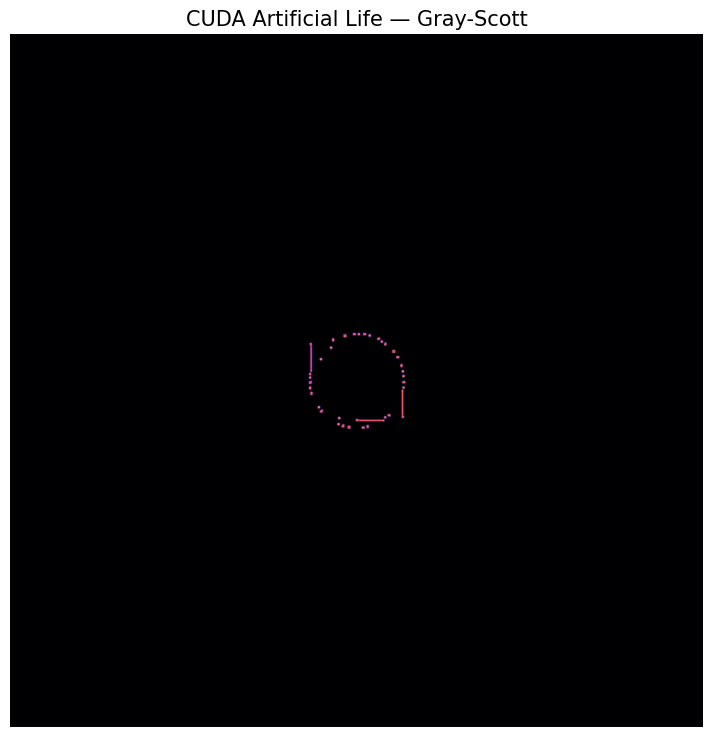

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import glob
import os

W = 1024
H = 1024

frames = sorted(
    glob.glob("frame_*.bin")
)

print("Frames:", len(frames))

fig, ax = plt.subplots(figsize=(9, 9))

for filename in frames:

    V = np.fromfile(
        filename,
        dtype=np.float32
    ).reshape(H, W)

    ax.clear()

    ax.imshow(
        V,
        cmap="magma",
        interpolation="bilinear",
        vmin=0.0,
        vmax=0.5
    )

    ax.set_title(
        "CUDA Artificial Life — Gray-Scott",
        fontsize=15
    )

    ax.axis("off")

    display(fig)

    clear_output(wait=True)

    time.sleep(0.03)

plt.close(fig)